# SVGP Saturated Example (single time dimension)
This notebook illustrates fitting a single multioutput SVGP with a LinearCoregionalization kernel composed of multiple SquaredExponential base kernels (distinct temporal dynamics). We simulate data from L=3 latent SE processes mixed into P=12 outputs, add Gaussian noise, fit an SVGP (Gaussian likelihood), and compare true vs recovered latents.

In [1]:
# Imports and configuration
import gpflow
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_probability as tfp

f64 = gpflow.utilities.to_default_float
RANDOM_SEED = 9102
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)


In [2]:
# Simulate single-time-dimension data with multiple latent SE processes
L = 3  # number of latent SE processes
P = 12  # number of outputs
N = 500  # number of time points
x_grid = np.linspace(-3, 3, N).reshape(-1, 1)
# Create L independent SE kernels for sampling true latents
kernels_latent = [gpflow.kernels.SquaredExponential(variance=2.0, lengthscales=0.5 + 0.5*i) for i in range(L)]
# Sample latent functions (mean zero) using kernel covariance matrices
latents = np.column_stack([
    np.random.multivariate_normal(np.zeros(N), k.K(x_grid) + 1e-6*np.eye(N)) for k in kernels_latent
])
# Mixing matrix (P x L) - hardcoded so each output is affected by a single latent
# e.g., with P=12 and L=3, assign 4 outputs per latent deterministically
block = max(1, P // L)
W_true = np.zeros((P, L))
for i in range(P):
    j = min(i // block, L-1)
    W_true[i, j] = 1.0
# small noise to break exact degeneracy (optional)
W_true += 0.01 * np.random.randn(P, L)
# Randomly flip the sign of some outputs' primary weights (introduce sign variability)
flip_prob = 0.3
flip_rows = np.random.rand(P) < flip_prob
W_true[flip_rows, :] *= -1
# Combine to produce output means (N x P)
Y_mean = latents @ W_true.T
# Add Gaussian noise for observations
sigma_noise = 0.1
Y = Y_mean + np.random.normal(scale=sigma_noise, size=Y_mean.shape)

print('Shapes: x_grid', x_grid.shape, 'latents', latents.shape, 'Y', Y.shape)

Shapes: x_grid (500, 1) latents (500, 3) Y (500, 12)


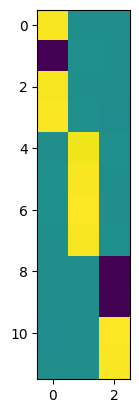

In [3]:
plt.imshow(W_true.round(2))

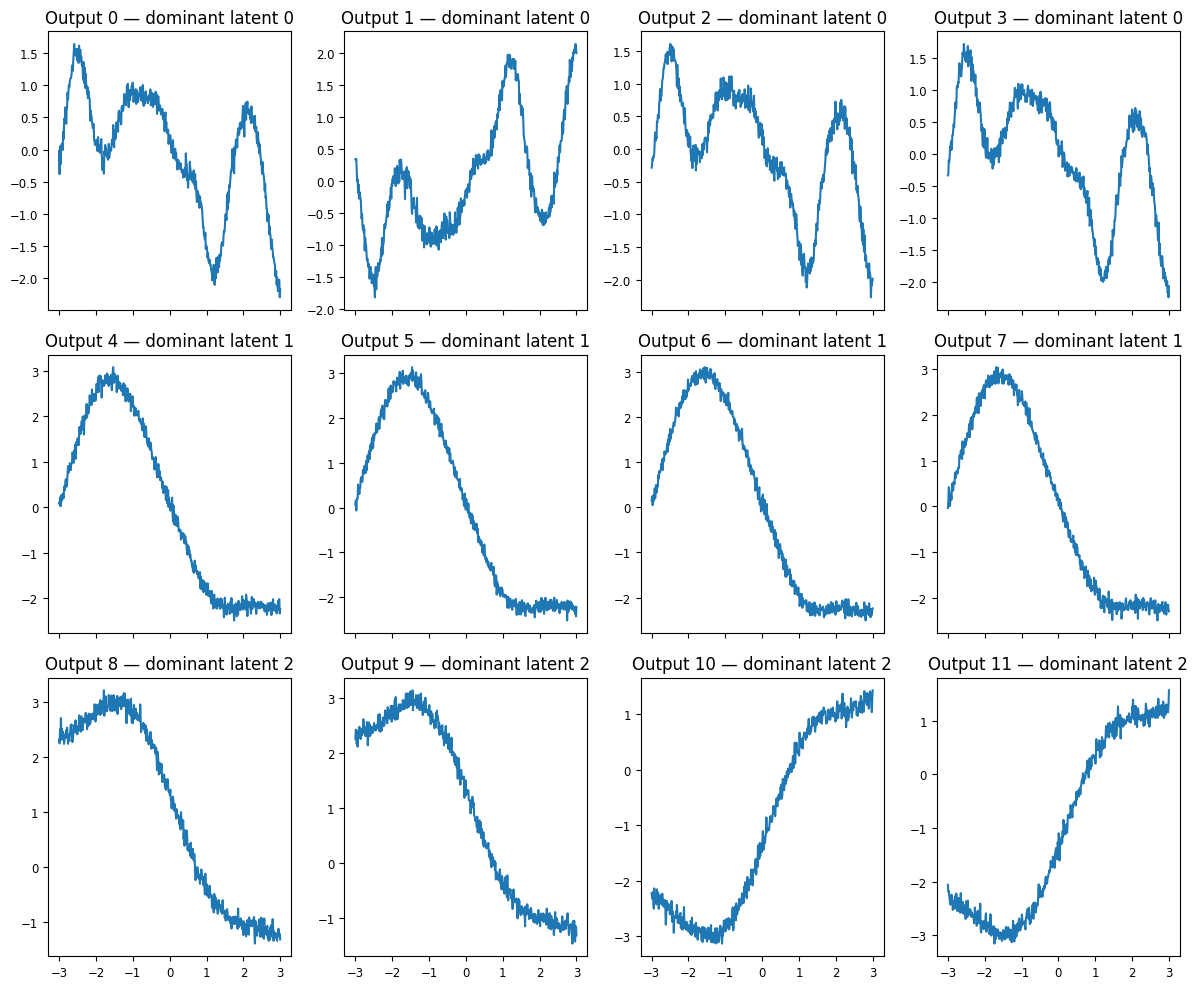

Group sizes by dominant latent:
 Latent 0: 4 outputs
 Latent 1: 4 outputs
 Latent 2: 4 outputs


In [4]:
# Plot simulated data: 4x3 grid of the 12 outputs, grouped by dominant latent
# Determine dominant latent for each output (by absolute weight)
dominant = np.argmax(np.abs(W_true), axis=1)  # shape (P,)
# Group output indices by dominant latent
grouped = [np.where(dominant == i)[0] for i in range(L)]
# Flatten groups to an ordered list (latent 0 then 1 then 2)
ordered = np.concatenate([g for g in grouped if g.size > 0])
# If some outputs not covered (unlikely), append remaining indices
remaining = [i for i in range(P) if i not in ordered]
if len(remaining) > 0:
    ordered = np.concatenate([ordered, np.array(remaining)])
# Plot in a 4x3 grid
fig, axs = plt.subplots(3, 4, figsize=(12, 10), sharex=True)
axs = axs.flatten()
for plot_idx, out_idx in enumerate(ordered):
    ax = axs[plot_idx]
    ax.plot(x_grid.flatten(), Y[:, out_idx], color='C0')
    ax.set_title(f'Output {out_idx} — dominant latent {dominant[out_idx]}')
    ax.tick_params(axis='both', which='major', labelsize='small')
# Hide any unused subplots if P < 12
for j in range(P, len(axs)):
    axs[j].axis('off')
plt.tight_layout()
plt.show()
# Quick check: print group sizes
print('Group sizes by dominant latent:')
for i,g in enumerate(grouped):
    print(f' Latent {i}: {g.size} outputs')

In [5]:
# Create training subset (sampled observations)
np.random.seed(RANDOM_SEED)
n_obs = 200
indices = np.random.choice(np.arange(N), size=n_obs, replace=False)
X_train = x_grid[indices].astype(np.float64)
Y_train = Y[indices, :].astype(np.float64)
print('Training shapes:', X_train.shape, Y_train.shape)

Training shapes: (200, 1) (200, 12)


In [6]:
# Calculate rank estimate
from scipy.linalg import svd

def calculate_rank_estimate(Y, threshold=0.99, transform_counts=True):
    """
    Calculate the rank Q that explains 'threshold' variance.
    Robust to skewed count data.
    """

    # 1. Log-transform counts, if desired
    if transform_counts:
        Y = np.log1p(Y)
    
    # 2. Center and scale (standardize)
    mean = np.mean(Y, axis=0)
    std = np.std(Y, axis=0) + 1e-6
    Y_standard = (Y - mean) / std

    # 3. Perform SVD on standardized data
    _, s, _ = svd(Y_standard, full_matrices=False)

    # 4. Calculate cumulative variance explained
    eigenvalues = s**2
    var_explained = eigenvalues / np.sum(eigenvalues)
    cumulative_var = np.cumsum(var_explained)
    
    # 5. Determine rank for cutoff value
    Q = np.argmax(cumulative_var >= threshold) + 1

    return int(Q)


q_est = calculate_rank_estimate(Y_train, transform_counts=False)
print(f"Estimated rank Q to explain 99% variance: {q_est}")

Estimated rank Q to explain 99% variance: 3


In [7]:
# Optimizer helper (adapted: fewer iterations for speed)
def optimize_multioutput_model(m, X, Y, hs_scale=0.1, orthog_weight=0.1, orthog_anneal_steps=1000, orthog_offdiag_only=True):
    m.kernel.W.prior = tfp.distributions.Horseshoe(f64(hs_scale))
    # Freeze variance parameters if helper exists
    try:
        utilities.freeze_variance_parameters(m.kernel)
    except Exception:
        pass
    adam_opt = tf.keras.optimizers.Adam(learning_rate=0.01)
    natgrad_opt = gpflow.optimizers.NaturalGradient(gamma=0.1)
    natgrad_vars = [(m.q_mu, m.q_sqrt)]
    gpflow.set_trainable(m.q_mu, False)
    gpflow.set_trainable(m.q_sqrt, False)
    num_iterations = 5000
    patience = 300
    best_loss = float('inf')
    iterations_no_improve = 0
    orthog_w_tf = tf.Variable(f64(0.0), trainable=False)
    def loss_fn():
        return m.training_loss((X, Y))
    @tf.function
    def optimization_step():
        natgrad_opt.minimize(loss_fn, var_list=natgrad_vars)
        with tf.GradientTape() as tape:
            loss = loss_fn()
            W = tf.convert_to_tensor(m.kernel.W)
            sign_penalty = tf.reduce_sum(tf.nn.relu(-W[0, :]))
            try:
                WTW = tf.matmul(tf.transpose(W), W)
                if orthog_offdiag_only:
                    offdiag = WTW - tf.linalg.tensor_diag(tf.linalg.diag_part(WTW))
                    orthog_penalty = tf.reduce_sum(tf.square(offdiag))
                else:
                    num_latent = tf.cast(tf.shape(W)[1], tf.int32)
                    identity = tf.eye(num_latent, dtype=W.dtype)
                    orthog_penalty = tf.reduce_sum(tf.square(WTW - identity))
            except Exception:
                orthog_penalty = f64(0.0)
            total_loss = loss + f64(1.0) * sign_penalty + orthog_w_tf * orthog_penalty
        grads = tape.gradient(total_loss, m.trainable_variables)
        clipped_grads = [tf.clip_by_norm(g, 1.0) if g is not None else None for g in grads]
        adam_opt.apply_gradients(zip(clipped_grads, m.trainable_variables))
        return total_loss, loss
    for i in range(num_iterations):
        cur_w = min(1.0, float(i) / float(orthog_anneal_steps)) * float(orthog_weight) if orthog_anneal_steps>0 else float(orthog_weight)
        orthog_w_tf.assign(f64(cur_w))
        total_loss, data_loss = optimization_step()
        loss_val = data_loss.numpy()
        if np.isnan(loss_val) or np.isinf(loss_val):
            print('Stopping due to NaN/Inf loss')
            break
        if loss_val < best_loss:
            best_loss = loss_val
            iterations_no_improve = 0
        else:
            iterations_no_improve += 1
            if iterations_no_improve >= patience:
                print(f'Early stopping at iter {i}')
                break
        if i % 250 == 0:
            print(f'Iter {i}: loss={loss_val:.6f}')
    print(f'Final loss: {best_loss:.6f}')
    return m

In [8]:
# Build SVGP: L SE base kernels, LinearCoregionalization mixing into P outputs
num_latent_gps = q_est #P
kern_list = [gpflow.kernels.SquaredExponential(active_dims=[0]) for _ in range(num_latent_gps)]
kernel = gpflow.kernels.LinearCoregionalization(kernels=kern_list, W=np.random.normal(size=(P, num_latent_gps)))
# Inducing points (shared)
M = 50
Z = np.linspace(np.min(X_train), np.max(X_train), M).reshape(-1, 1)
iv = gpflow.inducing_variables.SharedIndependentInducingVariables(gpflow.inducing_variables.InducingPoints(Z))
q_mu = np.zeros((M, num_latent_gps))
q_sqrt = np.repeat(np.eye(M)[None, ...], num_latent_gps, axis=0)
m_multi = gpflow.models.SVGP(kernel=kernel, likelihood=gpflow.likelihoods.Gaussian(), inducing_variable=iv, q_mu=q_mu, q_sqrt=q_sqrt, num_latent_gps=num_latent_gps)
# Optimize
m_multi = optimize_multioutput_model(m_multi, X_train, Y_train, hs_scale=0.1) # Previously used hs_scale=0.01
gpflow.utilities.print_summary(m_multi)

Instructions for updating:
Use fn_output_signature instead


Instructions for updating:
Use fn_output_signature instead


Iter 0: loss=5349.878928
Iter 250: loss=846.850799
Iter 500: loss=-1541.210415
Iter 750: loss=-1882.582402
Iter 1000: loss=-1908.752039
Iter 1250: loss=-1921.534412
Iter 1500: loss=-1926.364146
Iter 1750: loss=-1931.894723
Iter 2000: loss=-1941.730465
Iter 2250: loss=-1942.397989
Iter 2500: loss=-1943.853085
Iter 2750: loss=-1950.418790
Iter 3000: loss=-1946.585484
Iter 3250: loss=-1948.447834
Iter 3500: loss=-1954.416462
Iter 3750: loss=-1951.018133
Iter 4000: loss=-1960.516849
Iter 4250: loss=-1956.417788
Iter 4500: loss=-1956.854870
Early stopping at iter 4585
Final loss: -1965.384736
╒════════════════════════════════════════════╤═══════════╤══════════════════╤═══════════╤═════════════╤═════════════╤═════════╤═══════════════════════════════════════════════════════╕
│ name                                       │ class     │ transform        │ prior     │ trainable   │ shape       │ dtype   │ value                                                 │
╞════════════════════════════════════

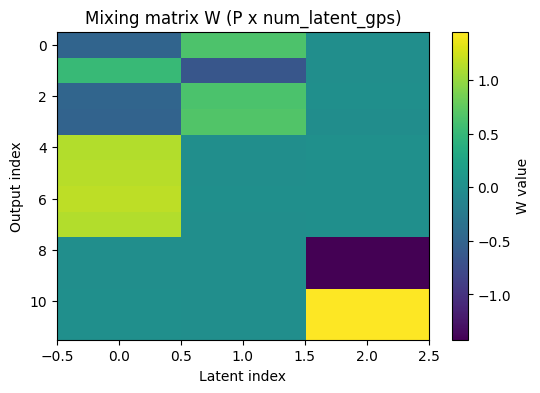

Top latent columns by norm: [2 0 1]
Column norms (top L): [2.86797387 2.48501892 1.3069039 ]


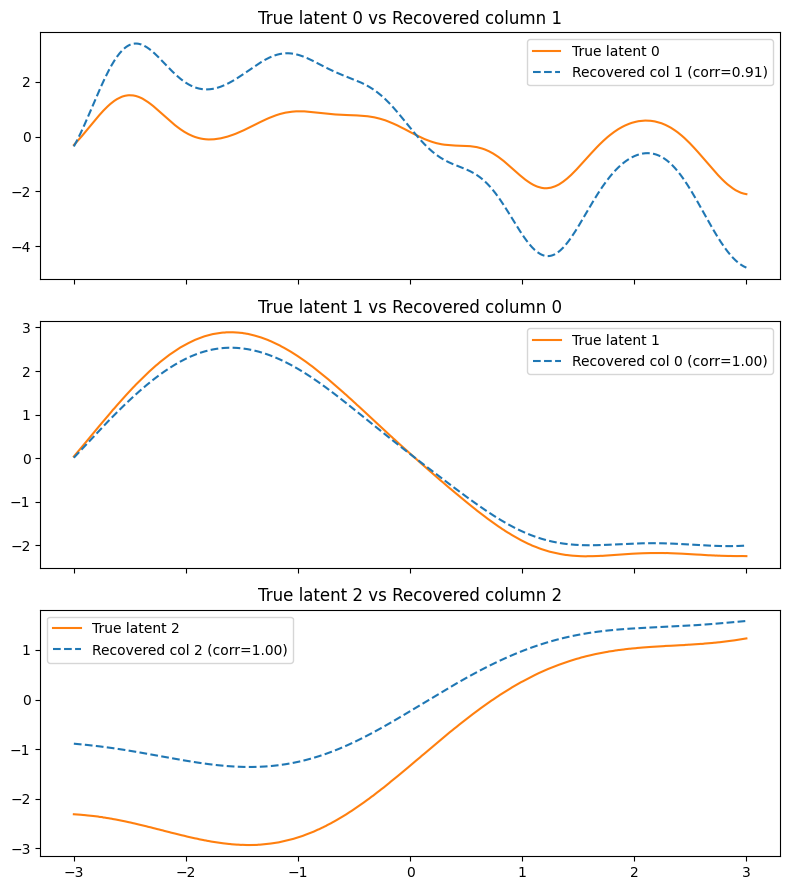

In [9]:
# Predict on full grid and analyze mixing matrix
X_grid_sorted = x_grid  # already ordered
mu_hat, var_hat = m_multi.predict_f(X_grid_sorted)
y_hat, y_var_hat = m_multi.predict_y(X_grid_sorted)
W_ = m_multi.kernel.W.numpy()
# 1) Plot W mixing matrix
plt.figure(figsize=(6, 4))
plt.imshow(W_, aspect='auto')
plt.colorbar(label='W value')
plt.xlabel('Latent index')
plt.ylabel('Output index')
plt.title('Mixing matrix W (P x num_latent_gps)')
plt.show()
# 2) Compute column norms and select top L columns (should recover L meaningful latents)
col_norms = np.linalg.norm(W_, axis=0)
top_idx = np.argsort(col_norms)[-L:][::-1]  # indices of top-L latent columns, descending
print('Top latent columns by norm:', top_idx)
print('Column norms (top L):', col_norms[top_idx])
# 3) Recover latent means using pseudo-inverse of W (project to output space)
l_mu_hat = mu_hat @ tf.transpose(tf.linalg.pinv(m_multi.kernel.W))  # shape (N, P)
l_mu_hat = l_mu_hat - tf.reduce_mean(l_mu_hat, axis=0)
l_mu_hat_np = l_mu_hat.numpy()
# Recover variances via approximate propagation (elementwise W squared inversion)
try:
    l_var_hat = tf.transpose(tf.linalg.pinv(tf.square(m_multi.kernel.W)) @ tf.transpose(var_hat))
    l_var_hat_np = l_var_hat.numpy()
except Exception as e:
    l_var_hat_np = np.zeros_like(l_mu_hat_np)
    print('Variance recovery failed:', e)
# 4) For each true latent, find best matching recovered column by correlation and plot
fig, axs = plt.subplots(L, 1, figsize=(8, 3*L), sharex=True)
if L == 1:
    axs = [axs]
for j in range(L):
    # compute correlations with all recovered columns
    corrs = [np.corrcoef(l_mu_hat_np[:, k], latents[:, j])[0, 1] for k in range(l_mu_hat_np.shape[1])]
    best_k = int(np.nanargmax(np.abs(corrs)))
    axs[j].plot(x_grid.flatten(), latents[:, j], label=f'True latent {j}', color='C1')
    axs[j].plot(x_grid.flatten(), l_mu_hat_np[:, best_k], '--', label=f'Recovered col {best_k} (corr={corrs[best_k]:.2f})', color='C0')
    axs[j].legend()
    axs[j].set_title(f'True latent {j} vs Recovered column {best_k}')
plt.tight_layout()
plt.show()

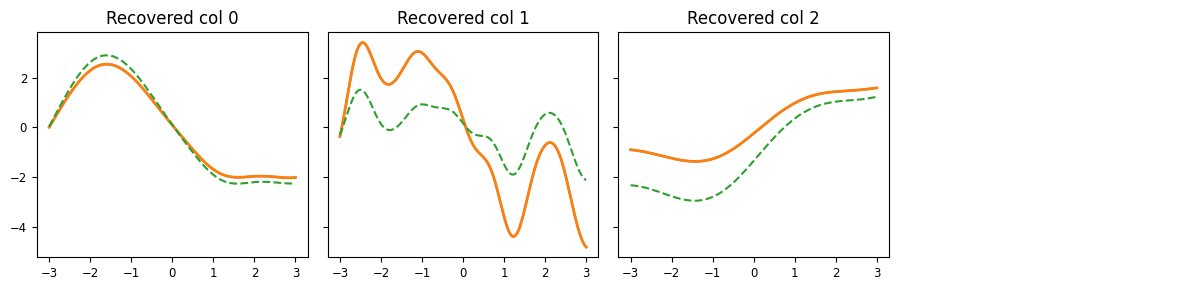

In [10]:
# Plot all recovered latent columns (P) in grid, highlight those matched to true latents
mu_hat, var_hat = m_multi.predict_f(x_grid)
# Recover to output-space columns using pseudo-inverse of W
l_mu_hat = mu_hat @ tf.transpose(tf.linalg.pinv(m_multi.kernel.W))
l_mu_hat = l_mu_hat - tf.reduce_mean(l_mu_hat, axis=0)
l_mu_hat_np = l_mu_hat.numpy()
W_ = m_multi.kernel.W.numpy()
P_rec = l_mu_hat_np.shape[1]
ncols = 4
nrows = int(np.ceil(P_rec / ncols))
fig, axs = plt.subplots(nrows, ncols, figsize=(12, 3*nrows), sharex=True, sharey=True)
axs = axs.flatten()
# find best matching column for each true latent
matched = []
for j in range(L):
    corrs = [np.corrcoef(l_mu_hat_np[:, k], latents[:, j])[0,1] for k in range(P_rec)]
    matched.append(int(np.nanargmax(np.abs(corrs))))
matched = np.unique(matched).tolist()
for k in range(P_rec):
    ax = axs[k]
    ax.plot(x_grid.flatten(), l_mu_hat_np[:, k], color='C0')
    if k in matched:
        ax.plot(x_grid.flatten(), l_mu_hat_np[:, k], color='C1', lw=2)
        corrs = [np.corrcoef(l_mu_hat_np[:, k], latents[:, j2])[0,1] for j2 in range(L)]
        best_j = int(np.nanargmax(np.abs(corrs)))
        ax.plot(x_grid.flatten(), latents[:, best_j], '--', color='C2', label=f'true {best_j} (corr={corrs[best_j]:.2f})')
    ax.set_title(f'Recovered col {k}')
    ax.tick_params(axis='both', which='major', labelsize='small')
for kk in range(P_rec, len(axs)):
    axs[kk].axis('off')
plt.tight_layout()
plt.show()